# 02 Disengagement Model

This notebook trains a Week 6 classifier for `Withdrawn/Fail = 1` versus `Pass/Distinction = 0`. The objective is an actionable staff alert. We first compare classifiers using cross-validated F1, PR-AUC, and ROC-AUC for the urgent alert, while retaining a separate F2 threshold for the high-recall watchlist. This keeps the precision/recall/F1 tradeoff visible instead of hard-coding a precision target.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from data_loader import OUT_DIR, WEEK_CUTOFF, audit_and_clean_data, ensure_dirs, load_data
from evaluation import plot_model_outputs
from features import build_weekly_base_features, make_enrollment_split
from modeling import build_week6_model_dataset, train_risk_model
from scoring import apply_engagement_score, derive_engagement_weights

pd.set_option("display.max_columns", 140)
sns.set_theme(style="whitegrid")
ensure_dirs()


## 1. Rebuild The Leakage-Safe Week 6 Dataset

The prediction point is Week 6. The feature table below uses registration/context fields, pre-start VLE activity, and Week 1-6 behaviour only. Final outcomes are used only as the supervised target.


In [2]:
raw_data = load_data()
data, audits = audit_and_clean_data(raw_data)
weekly_base = build_weekly_base_features(data)
split = make_enrollment_split(weekly_base)
weights, weight_rationale = derive_engagement_weights(weekly_base, split)
weekly = apply_engagement_score(weekly_base, weights)
weekly.to_csv(OUT_DIR / "weekly_engagement_features.csv", index=False)

audits["leakage"]


,candidate_feature,available_by_week6,used,reason
0,Pre-start VLE activity (negative dates),Yes,Yes,Observed before day 0; reflects eagerness to b...
1,Week 1-6 VLE clicks,Yes,Yes,Observed before the Week 6 prediction point.
2,Week 1-6 active days,Yes,Yes,Observed before the Week 6 prediction point.
3,Week 1-6 activity diversity,Yes,Yes,Observed before the Week 6 prediction point.
4,Early non-exam assessment submissions,Yes,Yes,Only due/submitted work by Week 6 is used.
5,Student demographics/context,Yes,Yes,Known at registration or course enrolment.
6,Engagement score,Yes,Yes,Computed from Week 1-6 behavior using train-de...
7,Final result,No,Target only,Used only to train/evaluate the supervised label.
8,Final exam score,No,No,Not available by Week 6.
9,Full-semester total clicks,No,No,Would leak future engagement behavior.


In [3]:
model_df = build_week6_model_dataset(weekly, data)
print(model_df.shape)
model_df.head()


(32593, 119)


,code_module,code_presentation,id_student,weekly_clicks_6,weekly_clicks_norm_6,active_days_last_7_6,study_regularity_score_6,click_gini_6,burstiness_score_6,week_to_week_volatility_6,material_active_days_6,recent_material_active_days_2w_6,material_click_share_6,content_click_ratio_6,quiz_click_ratio_6,homepage_dependency_ratio_6,forum_clicks_6,forum_active_days_6,forum_click_ratio_6,social_click_ratio_6,unique_sites_6,activity_entropy_6,activity_diversity_6,recent_clicks_2w_6,recent_activity_drop_6,click_trend_3w,consistency_rate_6,zero_click_weeks_6,days_since_last_click_6,longest_inactive_gap_6,inactive_last_7_days_6,inactive_last_14_days_6,first_click_day_6,on_schedule_click_ratio_6,ahead_click_ratio_6,catchup_click_ratio_6,avg_material_lag_6,planned_material_coverage_6,pace_metadata_coverage_ratio_6,assessment_submitted_ratio_6,missed_assessments_6,submitted_count_6,late_submission_count_6,early_submission_count_6,pre_assessment_clicks_7d_6,cram_ratio_6,prep_started_days_before_due_6,post_bad_score_recovery_clicks_6,punctuality_ratio_6,low_weight_completion_ratio_6,starting_early_score_6,avg_score_so_far_6,engagement_score_6,pre_start_clicks_6,pre_start_clicks_log_6,pre_start_active_days_6,days_before_start_6,pre_start_material_clicks_6,pre_start_flag_6,pre_start_proactivity_6,final_result,module_code,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,profile_activity_clicks_6,resource_clicks_6,resource_ratio_6,oucontent_clicks_6,oucontent_ratio_6,questionnaire_clicks_6,questionnaire_ratio_6,dataplus_clicks_6,dataplus_ratio_6,ouwiki_clicks_6,ouwiki_ratio_6,forumng_clicks_6,forumng_ratio_6,repeat_attempt_flag,high_credit_load_flag,low_imd_flag,active_week_ratio_6,early_submission_ratio_6,high_credit_low_engagement,motivation_proxy,education_level_ord,age_band_ord,mature_student_flag,young_student_flag,imd_midpoint,imd_missing_flag,high_imd_flag,attempt_count_capped,multiple_attempts_flag,credit_load_z_by_module,credits_per_active_day_6,higher_education_flag,lower_education_flag,prepared_mature_high_imd_profile,younger_lower_education_low_imd_profile,profile_group,week6_archetype,archetype_early_disengager_flag,archetype_burst_flag,archetype_compliance_flag,archetype_proactive_flag,credits_x_low_engagement,education_x_assessment_completion,age_x_study_regularity,attempts_x_low_engagement,low_imd_x_resource_ratio,higher_edu_x_oucontent_ratio,younger_lower_edu_x_resource_ratio,prepared_profile_x_questionnaire_ratio,risk_label
0,AAA,2013J,11391,389.0,0.486510,12.0,0.285714,0.221826,0.627161,43.308968,10.0,3.0,0.553514,0.553514,0.0,0.128383,78.0,6.0,0.151436,0.151436,46.0,1.091008,3.666667,86.0,-1.000000,30.0,0.833333,1,1.0,9.0,0,0,0.0,0.333333,0.000000,0.166667,0.166667,1.000000,0.149417,1.0,0.0,1.0,0.0,1.0,100.0,0.166667,2.0,0.0,1.0,1.0,1.0,78.0,50.4,98.0,4.595120,1.0,5.0,89.0,1,0.303916,Pass,AAA,M,HE Qualification,90-100%,55<=,0,240,N,325.0,9.0,0.027692,238.0,0.732308,0.0,0.0,0.0,0.0,0.0,0.0,78.0,0.240000,0,1,0,0.833333,1.0,1,0.0,3,2,1,0,95.0,0,1,0,0,3.548823,20.000000,1,0,1,0,prepared_mature_high_imd,mixed_engagement,0,0,0,0,119.04,3.0,0.571429,0.0,0.0,0.732308,0.0,0.0,0
1,AAA,2013J,28400,410.0,0.507180,15.0,0.357143,0.266677,0.612315,32.159757,13.0,2.0,0.379234,0.379234,0.0,0.188192,136.0,7.0,0.265907,0.265907,55.0,1.575840,4.000000,75.0,1.000000,-28.5,0.833333,1,7.0,7.0,1,0,0.0,0.186275,0.147059,0.000000,-0.119048,1.000000,0.055108,1.0,0.0,1.0,1.0,0.0,37.0,0.000000,3.0,0.0,0.0,1.0,0.0,70.0,27.3,215.0,5.375278,7.0,10.0,96.0,1,0.766319,Pass,AAA,F,HE Qualification,20-30%,35-55,0,60,N,258.0,0.0,0.000000,122.0,0.472868,0.0,0.0,0.0,0.0,0.0,0.0,136.0,0.527132,0,0,1,0.833333,0.0,0,0.0,3,1,1,0,25.0,0,0,0,0,0.000000,4.000000,1,0,0,0,higher_education,perfectionist_procrastinator,0,0,0,0,43.62,3.0,0.357143,0.0,0.0,0.472868,0.0,0.0,0
2,AAA,2013J,30268,179.0,0.255657,6.0,0.142857,0.070324,0.160501,0.000000,4.0,0.0,0.111089,0.111089,0.0,0.051899,87.0,4.0,0.170344,0.170344,23.0,0.552417,1.666667,0.0

## 1.1 Week 6 Archetype And Profile Features

Task 2 now explicitly carries forward the Task 1 engagement logic. The model includes `engagement_score_6` plus a leakage-safe `week6_archetype` inferred only from behaviour available by Week 6. It also includes transformed student-context features: ordered education level, IMD midpoint, age order, module-normalized credit load, repeat-attempt indicators, resource-mix ratios, and interpretable interaction terms.

The archetype/profile risk-prior columns are computed from the training split only inside `split_model_data`, so they do not use test labels.

In [4]:
feature_catalog = pd.read_csv(OUT_DIR / "task2_feature_catalog.csv")
feature_catalog

,bucket,feature,reason
0,Engagement,engagement_score_6,Latest leakage-safe Week 6 engagement score fr...
1,Engagement,week6_archetype,Most likely Week 6 behavioural archetype using...
2,Engagement,week6_archetype_risk_prior,Train-only risk rate for each Week 6 archetype.
3,Preparedness,education_level_ord,Ordered education ladder to capture prior acad...
4,Preparedness,higher_education_flag,"HE-or-higher indicator, motivated by outcome g..."
5,Socioeconomic context,imd_midpoint,Numeric deprivation band midpoint; used as con...
6,Socioeconomic context,low_imd_flag,Lower IMD context flag.
7,Life stage,age_band_ord,Ordered age band.
8,Life stage,mature_student_flag,Mature student support-context flag.
9,Workload,credit_load_z_by_module,Credits normalized against peers in the same m...


In [5]:
archetype_counts = (
    model_df.groupby("week6_archetype")
    .agg(enrolments=("risk_label", "size"), observed_withdraw_fail_rate=("risk_label", "mean"))
    .sort_values("observed_withdraw_fail_rate", ascending=False)
)
archetype_counts

,enrolments,observed_withdraw_fail_rate
week6_archetype,,
early_disengager,9766,0.872210
struggling_repeater,378,0.711640
high_workload_risk,1919,0.614382
mixed_engagement,2978,0.472129
surface_compliance_engager,434,0.398618
sporadic_burst_engager,10727,0.355272
perfectionist_procrastinator,2998,0.324216
steady_engager,176,0.278409
proactive_engager,3217,0.258315


In [6]:
profile_counts = (
    model_df.groupby("profile_group")
    .agg(enrolments=("risk_label", "size"), observed_withdraw_fail_rate=("risk_label", "mean"))
    .sort_values("observed_withdraw_fail_rate", ascending=False)
)
profile_counts

,enrolments,observed_withdraw_fail_rate
profile_group,,
younger_lower_education_low_imd,2512,0.710987
low_imd,3579,0.568595
mixed_profile,21459,0.522205
higher_education,4041,0.452858
prepared_mature_high_imd,1002,0.350299


In [7]:
forbidden_tokens = ["final_result", "date_unregistration", "exam", "module_presentation_length"]
feature_columns = [c for c in model_df.columns if c not in ["risk_label", "final_result"]]
[c for c in feature_columns if any(token in c.lower() for token in forbidden_tokens)]


[]

## 2. Feature Screening For The Model

This is intentionally simple: we inspect correlations and feature distributions before model training. The goal is not to blindly add every possible variable, but to keep features that have a behavioural story and measurable signal.


In [8]:
numeric_cols = model_df.select_dtypes(include="number").columns.drop("risk_label")
correlations = (
    model_df[numeric_cols.tolist() + ["risk_label"]]
    .corr(numeric_only=True)["risk_label"]
    .drop("risk_label")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
correlations.head(20).to_frame("risk_correlation")


,risk_correlation
engagement_score_6,-0.516443
weekly_clicks_norm_6,-0.507111
assessment_submitted_ratio_6,-0.485747
active_week_ratio_6,-0.473320
consistency_rate_6,-0.473320
zero_click_weeks_6,0.473320
missed_assessments_6,0.452782
archetype_early_disengager_flag,0.451035
education_x_assessment_completion,-0.442650
activity_diversity_6,-0.440968


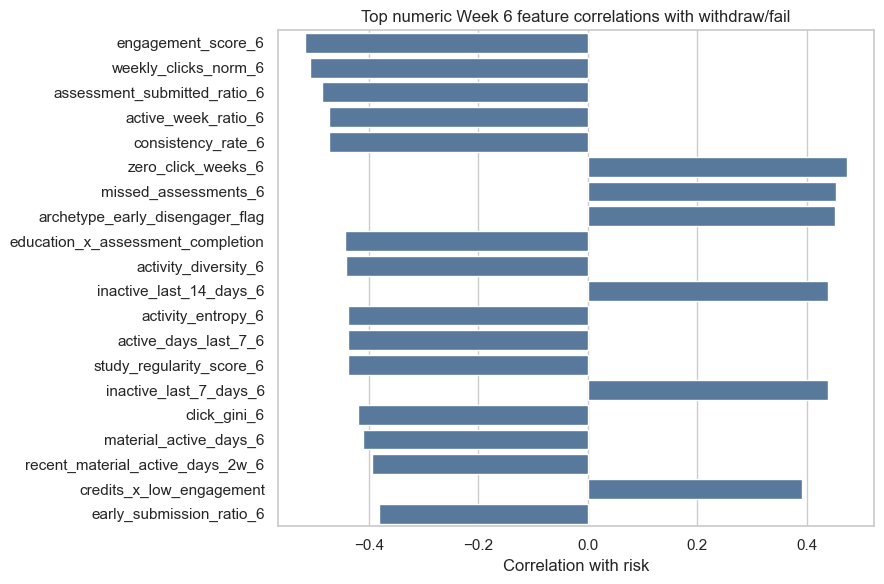

In [9]:
top_corr = correlations.head(20).reset_index()
top_corr.columns = ["feature", "risk_correlation"]
plt.figure(figsize=(9, 6))
sns.barplot(data=top_corr, y="feature", x="risk_correlation", color="#4C78A8")
plt.title("Top numeric Week 6 feature correlations with withdraw/fail")
plt.xlabel("Correlation with risk")
plt.ylabel("")
plt.tight_layout()


## 3. Compare Candidate Models

We compare Logistic Regression, Random Forest, KNN, calibrated Linear SVC, XGBoost, one regularized XGBoost variant, and Soft Voting. The XGBoost variant acts as a small controlled hyperparameter search over depth and regularization. For model comparison, cross-validated probabilities on the training split choose each model's F1 threshold for the urgent-alert use case. We also retain each model's F2 operating point as a broader watchlist because recall still matters in student support. The test set is held back until after the modelling choices are made.


In [10]:
model_result = train_risk_model(model_df, split)

model_result["model_comparison"][[
    "model_name", "precision", "recall", "f1", "f2", "pr_auc", "roc_auc", "selection_threshold", "alerts", "alert_rate"
]]


,model_name,precision,recall,f1,f2,pr_auc,roc_auc,selection_threshold,alerts,alert_rate
6,soft_voting,0.756297,0.823570,0.788501,0.809175,0.896333,0.864676,0.383685,14054,0.574947
4,xgboost,0.736615,0.845343,0.787242,0.821103,0.895548,0.863504,0.365225,14811,0.605916
5,xgboost_regularized,0.757347,0.816674,0.785893,0.804077,0.892266,0.859932,0.400365,13917,0.569342
0,logistic_regression,0.772892,0.793972,0.783290,0.789664,0.892431,0.859010,0.394955,13258,0.542383
1,random_forest,0.760532,0.807144,0.783145,0.797370,0.890265,0.857651,0.396961,13697,0.560342
3,linear_svc_calibrated,0.759669,0.795986,0.777404,0.788448,0.886942,0.851152,0.427626,13523,0.553224
2,knn,0.730947,0.810011,0.768450,0.792859,0.876078,0.838395,0.359431,14302,0.585092


In [11]:
model_result["overfit_check"][[
    "model_name", "evaluation", "precision", "recall", "f1", "roc_auc", "false_positives", "false_negatives", "alerts", "alert_rate"
]].sort_values(["model_name", "evaluation"])


,model_name,evaluation,precision,recall,f1,roc_auc,false_positives,false_negatives,alerts,alert_rate
5,knn,test,0.742285,0.827522,0.782590,0.850429,1236,742,4796,0.588538
4,knn,train_fit,1.000000,1.000000,1.000000,1.000000,0,0,12906,0.527982
7,linear_svc_calibrated,test,0.766858,0.808926,0.787330,0.859609,1058,822,4538,0.556878
6,linear_svc_calibrated,train_fit,0.764479,0.797768,0.780769,0.855390,3172,2610,13468,0.550974
1,logistic_regression,test,0.776560,0.807066,0.791519,0.864457,999,830,4471,0.548656
0,logistic_regression,train_fit,0.776344,0.796916,0.786495,0.863348,2963,2621,13248,0.541973
3,random_forest,test,0.772221,0.821943,0.796307,0.867882,1043,766,4579,0.561909
2,random_forest,train_fit,0.820627,0.867426,0.843378,0.921185,2447,1711,13642,0.558092
13,soft_voting,test,0.762117,0.833333,0.796136,0.871943,1119,717,4704,0.577249
12,soft_voting,train_fit,0.774062,0.839377,0.805398,0.885924,3162,2073,13995,0.572533


## 4. Final Selected Model And Test Metrics

The selected classifier is chosen by validation F1, PR-AUC, and ROC-AUC for the urgent-alert workflow. The urgent threshold maximizes validation F1 to reduce false positives and improve the overall precision/recall balance; the watchlist threshold keeps the higher-recall F2 operating point for broader monitoring.


In [12]:
plot_model_outputs(model_result)

pd.DataFrame([
    {"tier": "selected", **model_result["primary_metrics"]},
    {"tier": "watchlist", **model_result["watchlist_metrics"]},
    {"tier": "capacity_20pct", **model_result["capacity_metrics"]},
])


,tier,threshold,precision,recall,f1,f2,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives,alerts,alert_rate,confusion_matrix,model_name,threshold_name,selection_rule
0,selected,0.383685,0.762117,0.833333,0.796136,0.818045,0.871943,0.901735,2728,1119,717,3585,4704,0.577249,"[[2728, 1119], [717, 3585]]",soft_voting,cv_max_f1,best_cv_f1_model_then_max_f1_alert_threshold
1,watchlist,0.188137,0.602831,0.970246,0.743631,0.864827,0.871943,0.901735,1097,2750,128,4174,6924,0.849675,"[[1097, 2750], [128, 4174]]",NaN,NaN,NaN
2,capacity_20pct,0.915390,0.993880,0.377499,0.547170,0.430952,0.871943,0.901735,3837,10,2678,1624,1634,0.200515,"[[3837, 10], [2678, 1624]]",NaN,NaN,NaN


<Figure size 500x400 with 0 Axes>

In [13]:
model_result["threshold_table"][[
    "threshold_name", "threshold", "precision", "recall", "f1", "roc_auc", "false_positives", "false_negatives", "alerts", "alert_rate"
]]


,threshold_name,threshold,precision,recall,f1,roc_auc,false_positives,false_negatives,alerts,alert_rate
0,urgent_balanced_f1,0.383685,0.762117,0.833333,0.796136,0.871943,1119,717,4704,0.577249
1,watchlist_f2,0.188137,0.602831,0.970246,0.743631,0.871943,2750,128,6924,0.849675
2,urgent_recall85,0.351751,0.735429,0.859368,0.792582,0.871943,1330,605,5027,0.616886
3,selected_cv_max_f1,0.383685,0.762117,0.833333,0.796136,0.871943,1119,717,4704,0.577249
4,capacity_10pct,0.994289,1.000000,0.198977,0.331912,0.871943,0,3446,856,0.105044
5,capacity_20pct,0.915390,0.993880,0.377499,0.547170,0.871943,10,2678,1634,0.200515
6,capacity_30pct,0.719494,0.942338,0.554626,0.698273,0.871943,146,1916,2532,0.310713
7,fixed_0.25,0.250000,0.653078,0.934682,0.768907,0.871943,2136,281,6157,0.755553
8,fixed_0.35,0.350000,0.733809,0.861227,0.792429,0.871943,1344,597,5049,0.619585
9,fixed_0.50,0.500000,0.840095,0.736402,0.784838,0.871943,603,1134,3771,0.462756


In [14]:
cm = model_result["primary_metrics"]["confusion_matrix"]
cm_df = pd.DataFrame(cm, index=["Actual pass/distinction", "Actual withdraw/fail"], columns=["Pred pass/distinction", "Pred withdraw/fail"])
cm_df


,Pred pass/distinction,Pred withdraw/fail
Actual pass/distinction,2728,1119
Actual withdraw/fail,717,3585


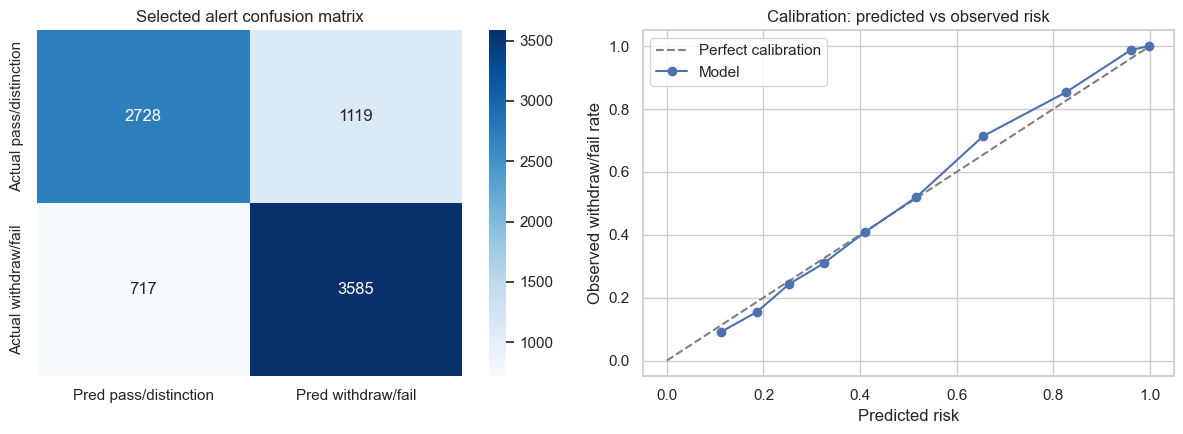

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Selected alert confusion matrix")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

calibration = model_result["calibration"]
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
axes[1].plot(calibration["mean_predicted_risk"], calibration["observed_risk_rate"], marker="o", label="Model")
axes[1].set_title("Calibration: predicted vs observed risk")
axes[1].set_xlabel("Predicted risk")
axes[1].set_ylabel("Observed withdraw/fail rate")
axes[1].legend()
plt.tight_layout()


## 5. Top Feature Drivers

Permutation importance is used so that the explanation works for both linear and non-linear models. A larger AUC drop means the model relied more on that feature.


In [16]:
model_result["feature_drivers"].head(12)


,feature,auc_drop,recall_drop
48,avg_score_so_far_6,0.024396,0.012785
29,first_click_day_6,0.023794,-0.018596
57,module_code,0.009632,-0.005114
49,engagement_score_6,0.009191,-0.025105
36,assessment_submitted_ratio_6,0.005580,-0.022548
1,weekly_clicks_norm_6,0.004393,-0.012552
39,late_submission_count_6,0.002913,-0.002092
107,education_x_assessment_completion,0.002261,-0.012320
106,credits_x_low_engagement,0.002103,-0.013250
89,imd_midpoint,0.001599,0.001162


In [17]:
model_result["behavioral_feature_drivers"].head(8)


,feature,auc_drop,recall_drop
0,engagement_score_6,0.009191,-0.025105
1,assessment_submitted_ratio_6,0.005580,-0.022548
2,weekly_clicks_norm_6,0.004393,-0.012552
3,late_submission_count_6,0.002913,-0.002092
4,imd_midpoint,0.001599,0.001162
5,weekly_clicks_6,0.000785,-0.001162
6,education_level_ord,0.000735,0.000465
7,starting_early_score_6,0.000334,-0.002092


## 6. Advisor Alert Design

The staff notification should be more than a probability. The high-recall F2 threshold is treated as a watchlist, while the balanced F1 threshold is the urgent advisor task tier. At the urgent threshold, an advisor receives:

- Student, module, presentation, and risk tier.
- Predicted risk percentage and model threshold used.
- Week-by-week engagement trajectory.
- Top behavioural drivers such as low engagement score, weak material-study frequency, late/missed assessments, poor recency, or low pre-start proactivity.
- Suggested action: send check-in within 48 hours, ask about workload/access/confidence, and offer an academic support session.

The selected classifier comes from validation performance, but the operating threshold is a product decision. The urgent tier uses the validation threshold that maximizes F1 to improve the balance between precision and recall; the watchlist keeps the higher-recall F2 threshold for broader monitoring. AUC does not change with the threshold, but alert volume, false positives, false negatives, precision, recall, and F1 do.
